> **VoxCity tutorial** — part of the [tutorial series](index.md). Before running, make sure VoxCity is [installed](../installation.md); most data sources also require [Google Earth Engine authentication](../guides/earth_engine.md).

# VoxCity Solar Irradiance Analysis

Calculate **instantaneous** and **cumulative** solar irradiance using EPW (EnergyPlus Weather) data and 3D ray-tracing through your voxel city model.

## What This Notebook Covers

| Analysis Type | Description |
|---------------|-------------|
| **Instantaneous** | Solar irradiance at a specific date/time |
| **Cumulative** | Total solar irradiance over a time period |

## Key Features

- Automatic EPW weather file download based on location
- Direct Normal Irradiance (DNI) and Diffuse Horizontal Irradiance (DHI) modeling
- Shadow casting through 3D voxel geometry
- Tree canopy transmissivity
- Export colored OBJ meshes for visualization

## Prerequisites

```python
pip install voxcity
```

In [1]:
# Installation (uncomment if running in a fresh environment)
# %pip install voxcity
# %pip install contextily osmnx geopandas matplotlib timezonefinder


In [2]:
import ee
from voxcity.geoprocessor.draw import draw_rectangle_map_cityname, center_location_map_cityname
from voxcity.generator import get_voxcity
from voxcity.simulator.solar import get_global_solar_irradiance_using_epw

# Authenticate & initialize Earth Engine (only needed if you plan to download data via GEE in your pipeline)
# ee.Authenticate()
# ee.Initialize(project='your-project-id')

cityname = "Tokyo, Japan"
meshsize = 5

# Option A: Draw rectangle interactively around a city
# m, rectangle_vertices = draw_rectangle_map_cityname(cityname, zoom=15)
# m  # display the map, draw a rectangle, then capture rectangle_vertices

# Option B: Click to set center with fixed width/height (meters)
# m, rectangle_vertices = center_location_map_cityname(cityname, east_west_length=500, north_south_length=500, zoom=15)
# m

# Option C: Provide rectangle vertices directly (lon, lat) if known
rectangle_vertices = [
    (139.760, 35.680),  # SW
    (139.760, 35.690),  # NW
    (139.770, 35.690),  # NE
    (139.770, 35.680)   # SE
]


INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (139.7650, 35.6850): Japan
2026-10-01 11:45:02,034 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=DeltaDTM | https://gee-community-catalog.org/projects/delta_dtm/
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.utils.cache | Using cached load_land_cover_gdf_from_osm result (558fc952250ea74f794cad562955e993.pkl)
INFO | voxcity.voxcity.utils.cache | U


  • Land Cover:  OpenStreetMap
  • Building:    OpenStreetMap
  • Canopy:      High Resolution 1m Global Canopy Height Maps
  • DEM:         DeltaDTM
------------------------------------------------------------
Downloading... (this may take a moment)


2026-10-01 11:45:02,554 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"
2026-10-01 11:45:02,875 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"


...

  ✓ Dem complete (2/4)


2026-10-01 11:45:05,788 - WARNING - Encountered 403 Forbidden with reason "PERMISSION_DENIED"


  ✓ Canopy complete (3/4)


INFO | voxcity.voxcity.generator.pipeline | Repairing canopy grid from land cover after parallel downloads (canopy source 'High Resolution 1m Global Canopy Height Maps' fell back without a usable land-cover mask).


  ✓ Land Cover complete (4/4)
------------------------------------------------------------
All downloads complete!



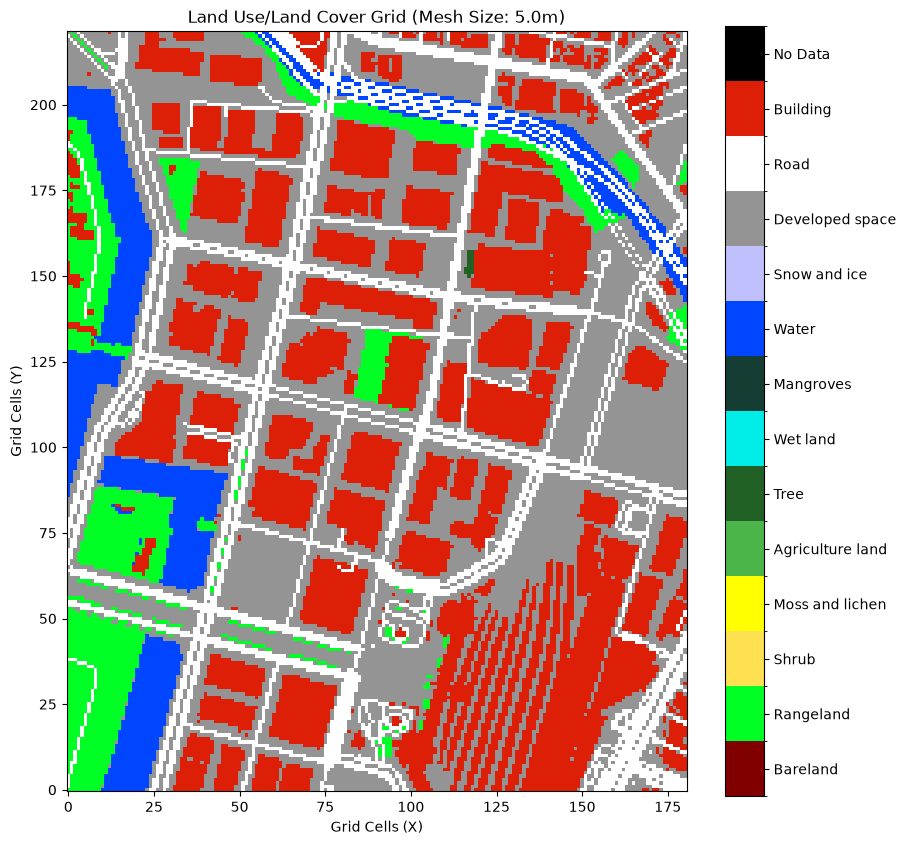

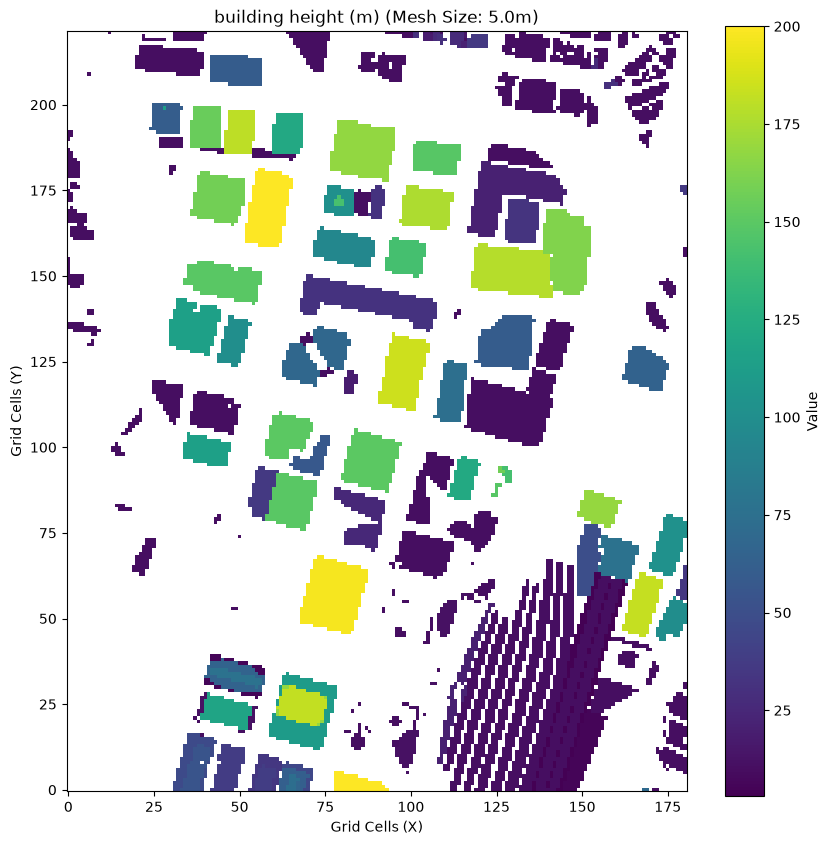

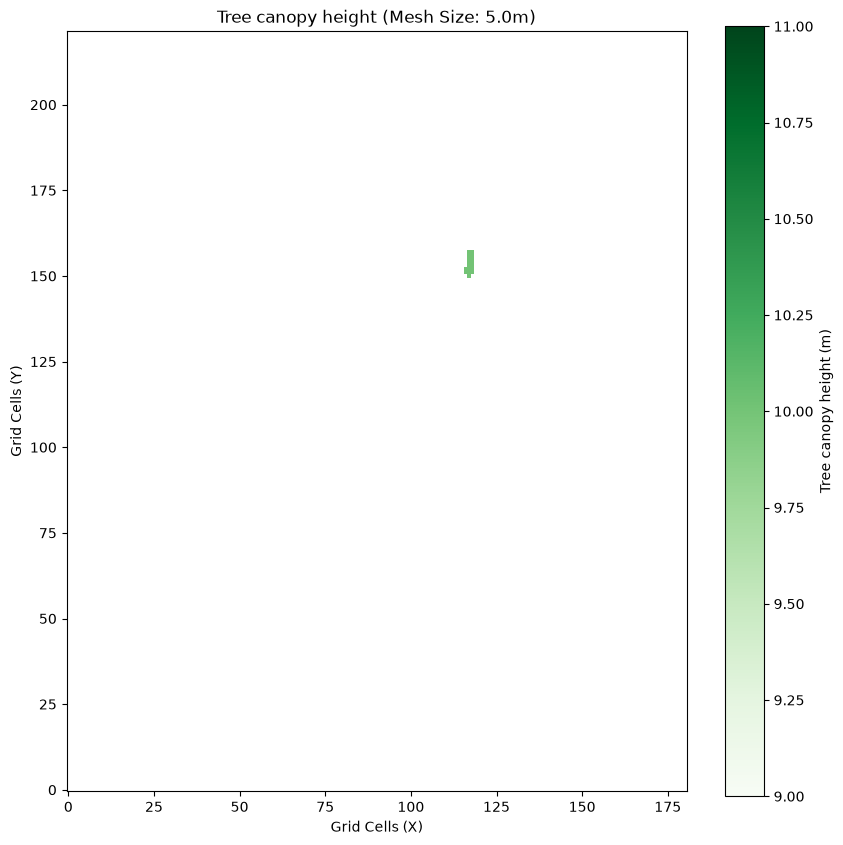

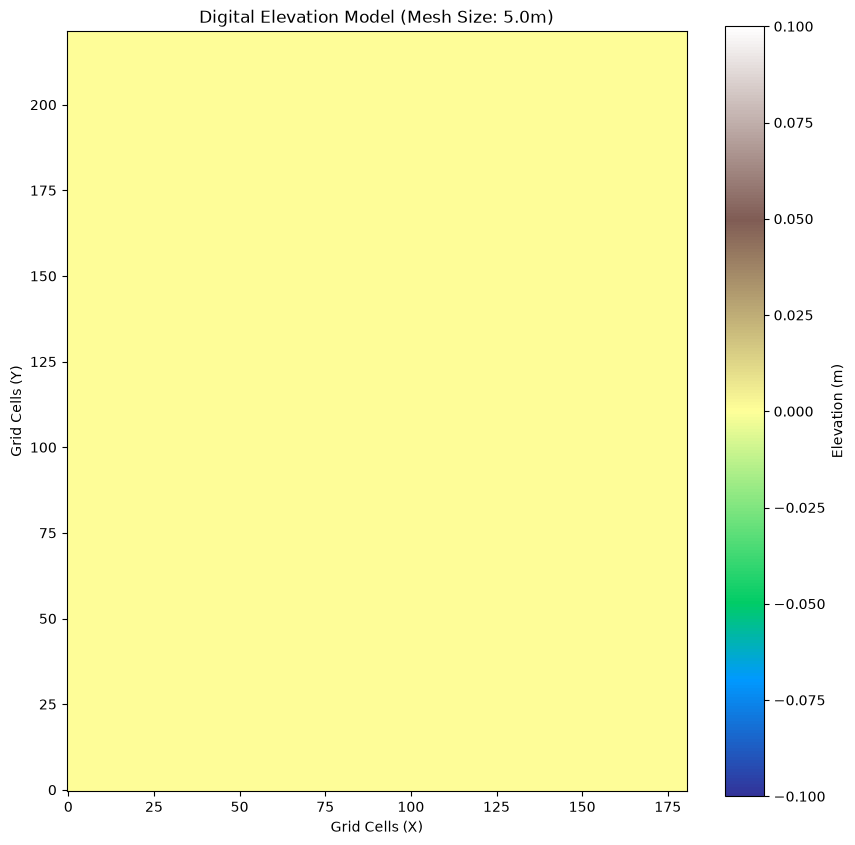

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/solar_demo/voxcity.h5
(222, 181, 41) (222, 181)


In [3]:
building_source = 'OpenStreetMap'
land_cover_source = 'OpenStreetMap'
canopy_height_source = 'High Resolution 1m Global Canopy Height Maps'
dem_source = 'DeltaDTM'

kwargs = {
    "output_dir": "output/solar_demo",
    # Optional DEM smoothing when reading GeoTIFF sources internally
    "dem_interpolation": True,
}

city = get_voxcity(
    rectangle_vertices,
    meshsize=meshsize,
    building_source=building_source,
    land_cover_source=land_cover_source,
    canopy_height_source=canopy_height_source,
    dem_source=dem_source,
    **kwargs
)

# Access grids from the VoxCity object
voxcity_grid = city.voxels.classes
dem_grid = city.dem.elevation

print(voxcity_grid.shape, dem_grid.shape)


---
## Instantaneous Solar Irradiance

Calculate global solar irradiance at a **specific date and time**.

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `calc_time` | Date and time in format "MM-DD HH:MM:SS" |
| `download_nearest_epw` | Auto-download nearest weather file |
| `tree_k` | Tree extinction coefficient |
| `tree_lad` | Leaf Area Density |
| `direct_normal_irradiance_scaling` | Scale factor for DNI |
| `diffuse_irradiance_scaling` | Scale factor for DHI |

Auto-detected regions: Asia, Japan
Fetching weather station data from Climate.OneBuilding.Org...
Scanning Asia...
Found 11757 stations in Asia
Scanning Japan...
Found 157 stations in Japan
Scanning India...
Found 6 stations in India
Scanning CSWD...
Found 270 stations in CSWD
Scanning CityUHK...
Found 1 stations in CityUHK
Scanning PHIKO...
Found 22 stations in PHIKO

Total stations found: 12213


Downloaded EPW file for Tokyo-Chiyoda TK JPN
Distance: 1.45 km
Station coordinates: 139.75116666666668, 35.69166666666667
WMO: 476620
Climate zone: 3A - Warm - Humid
Data period: 2004-2017
Files saved:
- EPW: output\tokyo-chiyoda_tk_jpn_2.epw
- Metadata: output\tokyo-chiyoda_tk_jpn_2.json

Loading EPW data...
Loaded 8760 hourly records


INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/solar_demo with the base name "instantaneous_solar_irradiance".
INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/solar_demo with the base name "instantaneous_solar_irradiance".
INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/solar_demo with the base name "instantaneous_solar_irradiance".


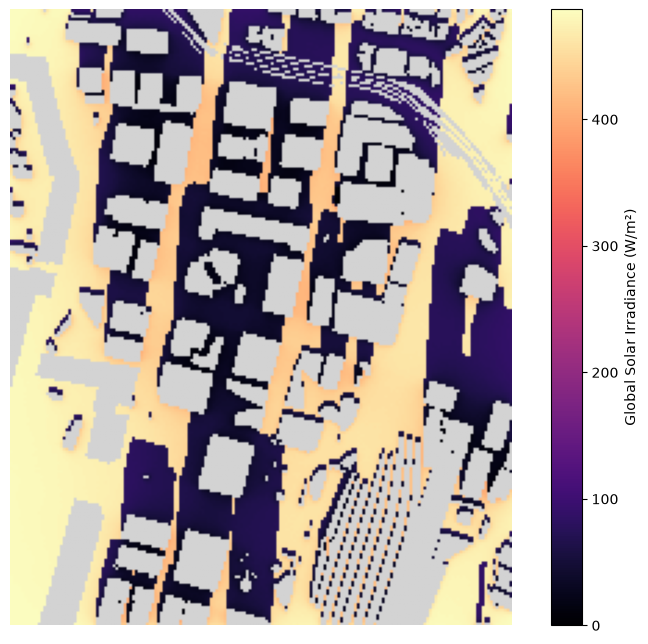

INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/solar_demo with the base name "instantaneous_solar_irradiance".


(222, 181)

In [4]:
solar_kwargs = {
    "download_nearest_epw": True,
    "rectangle_vertices": rectangle_vertices,
    # Or set a local EPW directly:
    # "epw_file_path": "./output/your_city.epw",
    "calc_time": "01-01 12:00:00",
    "view_point_height": 1.5,
    "tree_k": 0.6,
    "tree_lad": 1.0,
    "colormap": "magma",
    "obj_export": True,
    "output_directory": "output/solar_demo",
    "output_file_name": "instantaneous_solar_irradiance",
    "alpha": 1.0,
    "vmin": 0,
    # "vmax": 900,
}

solar_grid = get_global_solar_irradiance_using_epw(
    city,
    calc_type='instantaneous',
    direct_normal_irradiance_scaling=1.0,
    diffuse_irradiance_scaling=1.0,
    **solar_kwargs
)

solar_grid.shape


---
## Cumulative Solar Irradiance

Calculate **total solar irradiance** over a time period (e.g., daily, monthly, seasonal).

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `start_time` | Start of accumulation period (MM-DD HH:MM:SS) |
| `end_time` | End of accumulation period (MM-DD HH:MM:SS) |
| `time_step_minutes` | Time step for integration |
| `start_hour` / `end_hour` | Restrict calculation to certain hours (e.g., 8AM-6PM) |

**Note:** Cumulative calculations can be computationally intensive for large areas/long time periods.

Auto-detected regions: Asia, Japan
Fetching weather station data from Climate.OneBuilding.Org...
Scanning Asia...
Found 11757 stations in Asia
Scanning Japan...
Found 157 stations in Japan
Scanning India...
Found 6 stations in India
Scanning CSWD...
Found 270 stations in CSWD
Scanning CityUHK...
Found 1 stations in CityUHK
Scanning PHIKO...
Found 22 stations in PHIKO

Total stations found: 12213


Downloaded EPW file for Tokyo-Chiyoda TK JPN
Distance: 1.45 km
Station coordinates: 139.75116666666668, 35.69166666666667
WMO: 476620
Climate zone: 3A - Warm - Humid
Data period: 2004-2017
Files saved:
- EPW: output\tokyo-chiyoda_tk_jpn_3.epw
- Metadata: output\tokyo-chiyoda_tk_jpn_3.json

Loading EPW data...
Loaded 8760 hourly records
Numba threads: 4 (requested 4)


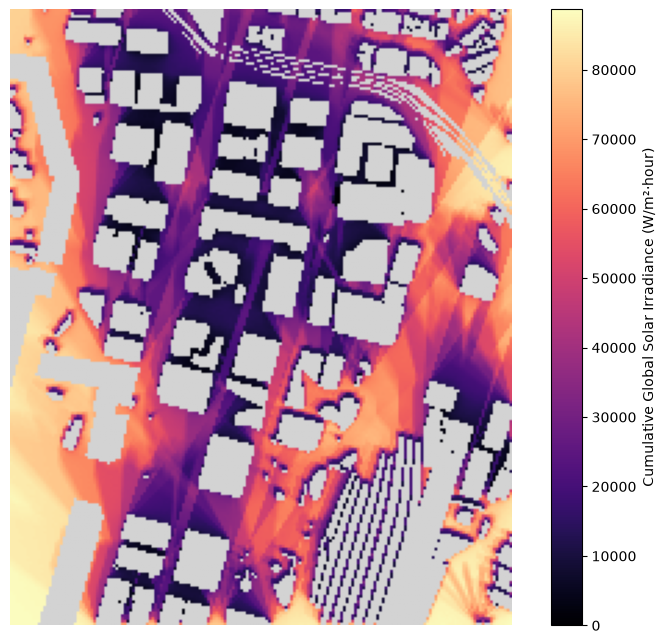

INFO | voxcity.voxcity.exporter.obj | OBJ and MTL files have been generated in output/solar_demo with the base name "cumulative_solar_irradiance".


(222, 181)

In [5]:
cum_kwargs = solar_kwargs.copy()
# Define the time window for accumulation
cum_kwargs["start_time"] = "01-01 05:00:00"
cum_kwargs["end_time"] = "01-31 20:00:00"

# Optionally restrict hours each day (e.g., 8AM–4PM)
cum_kwargs["start_hour"] = 8
cum_kwargs["end_hour"] = 16

# Performance controls (internal numba threads)
cum_kwargs["numba_num_threads"] = 4
cum_kwargs["progress_report"] = True

cum_kwargs["output_file_name"] = "cumulative_solar_irradiance"

cum_solar_grid = get_global_solar_irradiance_using_epw(
    city,
    calc_type='cumulative',
    direct_normal_irradiance_scaling=1.0,
    diffuse_irradiance_scaling=1.0,
    **cum_kwargs
)

cum_solar_grid.shape


## Tips
- If EPW download fails due to SSL, consider `allow_insecure_ssl=True` or `allow_http_fallback=True` in kwargs.
- To avoid repeated downloads, set `download_nearest_epw=False` and provide `epw_file_path`.
- Adjust `tree_k` and `tree_lad` to tune vegetation transmittance.
